# LSM ML Model Comparison

Compares Stage Six models from `README.md`:
- Logistic Regression
- Random Forest
- Support Vector Machine

Also includes predicted-vs-actual plots and quick sanity checks.

In [2]:
import pathlib, sys
repo_root = pathlib.Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml.lsm_ols_baseline import price_american_ols
from ml.lsm_ml_models import (
    price_american_logistic_regression,
    price_american_random_forest,
    price_american_svm,
)


In [4]:
params = dict(
    S0=100.0,
    K=100.0,
    r=0.05,
    sigma=0.2,
    T=1.0,
    num_paths=20000,
    steps=50,
    seed=123,
    call=False,
    antithetic=True,
    include_all_paths=False,
)
params


{'S0': 100.0,
 'K': 100.0,
 'r': 0.05,
 'sigma': 0.2,
 'T': 1.0,
 'num_paths': 20000,
 'steps': 50,
 'seed': 123,
 'call': False,
 'antithetic': True,
 'include_all_paths': False}

In [5]:
ols = price_american_ols(**params)
rf = price_american_random_forest(**params)
svm = price_american_svm(**params)
logit = price_american_logistic_regression(**params)

rows = [
    {"model": "OLS baseline", "price": ols.price, "stderr": ols.stderr},
    {"model": "Random Forest", "price": rf.price, "stderr": rf.stderr},
    {"model": "SVM", "price": svm.price, "stderr": svm.stderr},
    {"model": "Logistic Regression", "price": logit.price, "stderr": logit.stderr},
]
price_table = pd.DataFrame(rows).sort_values("price", ascending=False)
price_table


,model,price,stderr
1,Random Forest,10.437396,0.065425
0,OLS baseline,6.013846,0.050117
3,Logistic Regression,5.525137,0.050414
2,SVM,4.464463,0.035643


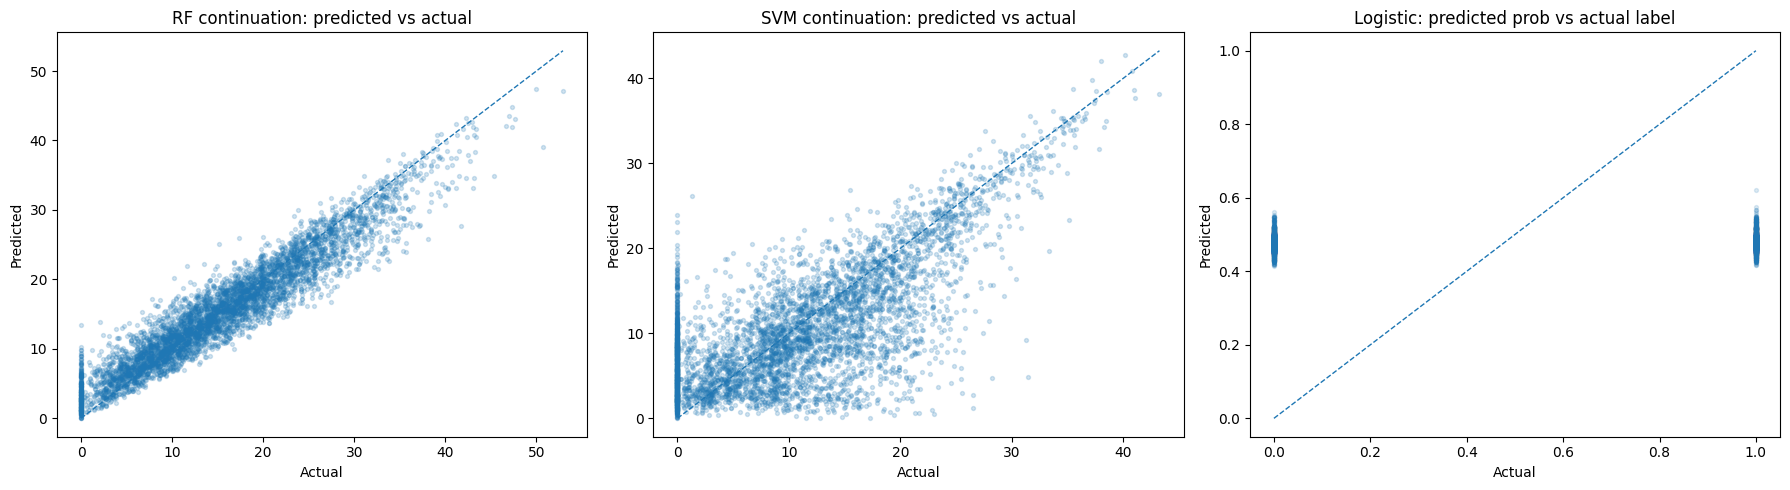

In [6]:
def scatter_pred_actual(ax, y_true, y_pred, title, alpha=0.2):
    n = min(len(y_true), 5000)
    if n == 0:
        ax.set_title(title + " (no data)")
        return
    idx = np.linspace(0, len(y_true) - 1, n).astype(int)
    yt = np.asarray(y_true)[idx]
    yp = np.asarray(y_pred)[idx]
    ax.scatter(yt, yp, s=8, alpha=alpha)
    lo, hi = float(min(yt.min(), yp.min())), float(max(yt.max(), yp.max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_pred_actual(axes[0], rf.diagnostics["continuation_true"], rf.diagnostics["continuation_pred"], "RF continuation: predicted vs actual")
scatter_pred_actual(axes[1], svm.diagnostics["continuation_true"], svm.diagnostics["continuation_pred"], "SVM continuation: predicted vs actual")
scatter_pred_actual(axes[2], logit.diagnostics["exercise_label_true"], logit.diagnostics["exercise_prob_pred"], "Logistic: predicted prob vs actual label", alpha=0.15)
plt.tight_layout()
plt.show()


In [7]:
# Price-level predicted vs baseline across a small S0 grid
s0_grid = np.linspace(80.0, 120.0, 9)
baseline_prices = []
rf_prices = []
svm_prices = []
logit_prices = []

for s0 in s0_grid:
    p = dict(params)
    p["S0"] = float(s0)
    baseline_prices.append(price_american_ols(**p).price)
    rf_prices.append(price_american_random_forest(**p).price)
    svm_prices.append(price_american_svm(**p).price)
    logit_prices.append(price_american_logistic_regression(**p).price)

plt.figure(figsize=(9, 5))
plt.plot(s0_grid, baseline_prices, marker="o", label="OLS baseline")
plt.plot(s0_grid, rf_prices, marker="o", label="Random Forest")
plt.plot(s0_grid, svm_prices, marker="o", label="SVM")
plt.plot(s0_grid, logit_prices, marker="o", label="Logistic Regression")
plt.xlabel("S0")
plt.ylabel("American price")
plt.title("Predicted option prices vs baseline across S0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


KeyboardInterrupt: 

In [8]:
# Simple sanity checks
assert np.isfinite(price_table["price"]).all(), "Non-finite prices found"
assert (price_table["price"] >= 0.0).all(), "Negative option prices found"
assert (price_table["stderr"] >= 0.0).all(), "Negative standard errors found"

price_table


,model,price,stderr
1,Random Forest,10.437396,0.065425
0,OLS baseline,6.013846,0.050117
3,Logistic Regression,5.525137,0.050414
2,SVM,4.464463,0.035643


In [9]:
from ml.lsm_ml_evaluation_protocol import run_evaluation_protocol

res = run_evaluation_protocol(
    show_progress=True,
    generate_plots=True,
    write_outputs=True,
)


[run] 1/3 experiment=baseline_rmse baseline_steps=100 seed=101 steps=100 paths=1000
[scenario] seed=101 1/40 K=80.00 T=0.0833 bucket=OTM
[train] seed=101 model=ols K=80.00 T=0.0833 t= 99/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 89/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 79/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 69/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 59/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 49/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 39/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 29/99 selected=    0 fit_mse=nan status=no_mask
[train] seed=101 model=ols K=80.00 T=0.0833 t= 19/99 selected=    0 fit_mse=nan status=no_mask
[train] 

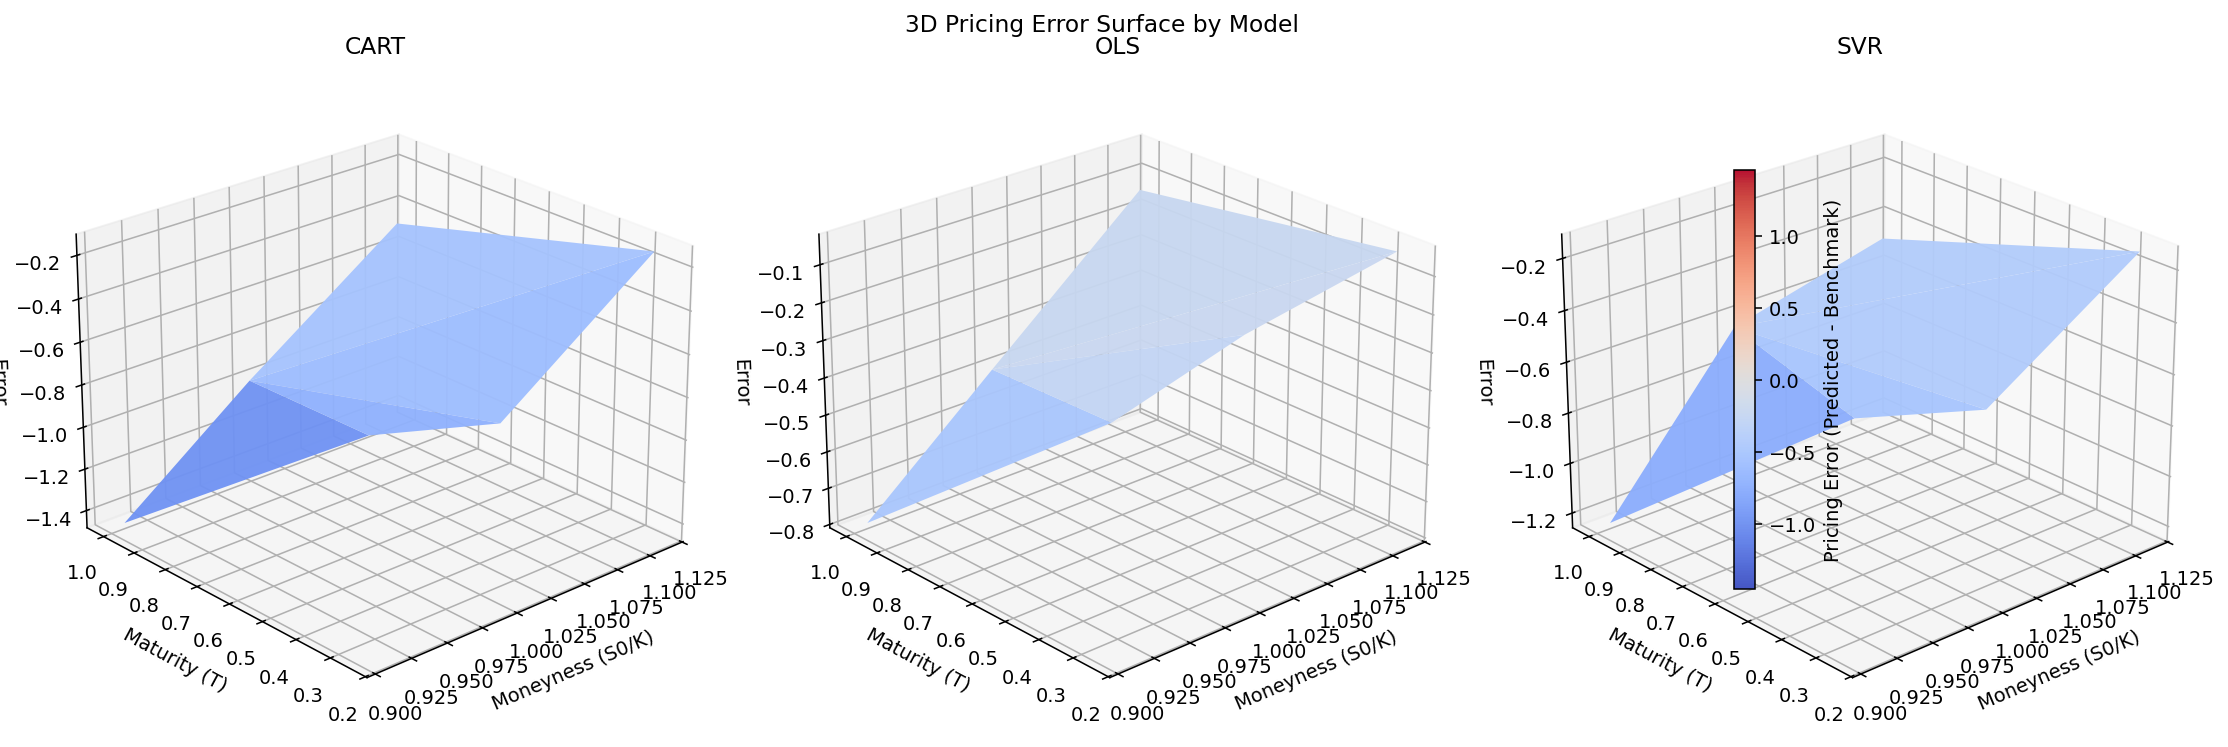

In [10]:
from IPython.display import Image, display
display(Image("/Users/samgrant/Desktop/Fin_Math/results/summary/american_lsm_ml_error_surface_3d.png"))

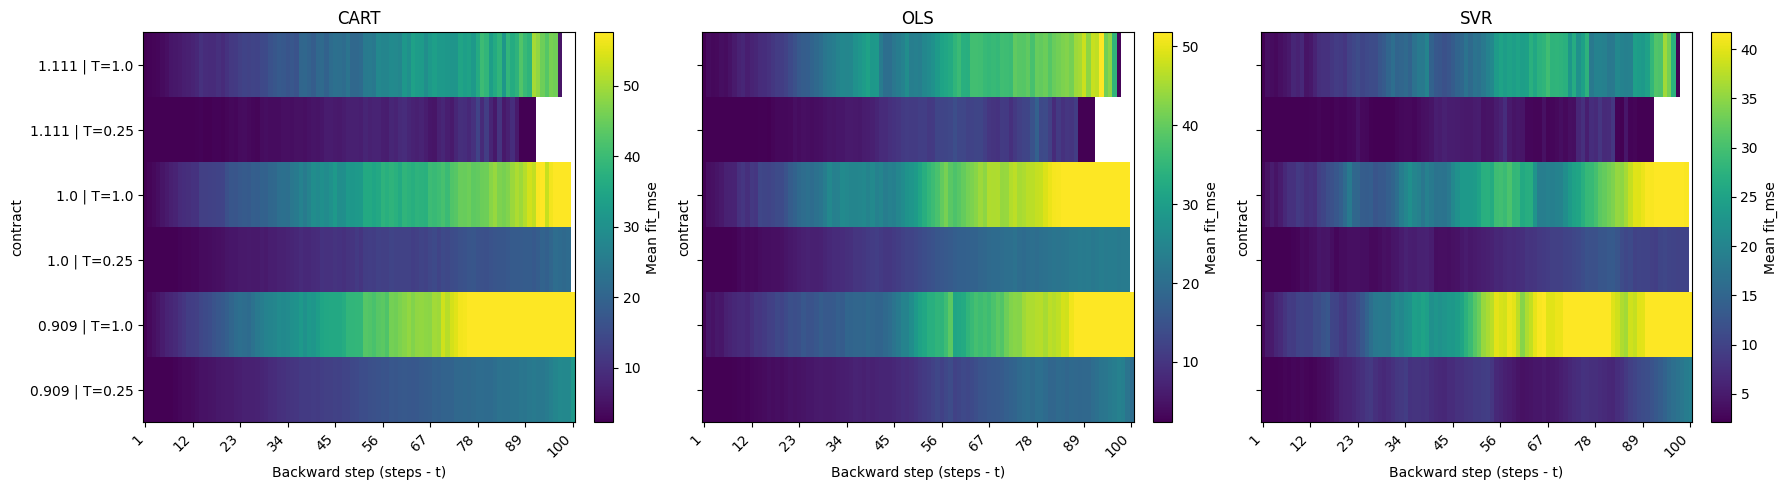

In [15]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

trace_csv = "/Users/samgrant/Desktop/Fin_Math/results/summary/american_lsm_ml_training_trace.csv"
df = pd.read_csv(trace_csv)
df = df[df["fit_mse"].notna() & (df["experiment"] == "baseline_rmse")].copy()
df["backward_step"] = df["steps"] - df["t"]

# Choose one:
# y_col = "moneyness"
# y_col = "T"
df["contract"] = df["moneyness"].round(3).astype(str) + " | T=" + df["T"].astype(str)
y_col = "contract"   # best for your current coarse grid

agg = (
    df.groupby(["model", y_col, "backward_step"], as_index=False)["fit_mse"]
      .mean()
      .rename(columns={"fit_mse": "fit_mse_mean"})
)

models = sorted(agg["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    p = (agg[agg["model"] == model]
         .pivot(index=y_col, columns="backward_step", values="fit_mse_mean")
         .sort_index()
         .sort_index(axis=1))

    z = p.to_numpy(dtype=float)

    # robust per-model scaling (prevents "all yellow" saturation)
    vals = z[np.isfinite(z)]
    vmin = np.quantile(vals, 0.05)
    vmax = np.quantile(vals, 0.95)
    if np.isclose(vmin, vmax):
        vmin, vmax = vals.min(), vals.max()

    im = ax.imshow(
        z,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    # ticks
    x_labels = p.columns.to_numpy()
    x_ticks = np.linspace(0, len(x_labels)-1, min(10, len(x_labels))).astype(int)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(int(x_labels[i])) for i in x_ticks], rotation=45, ha="right")

    y_labels = p.index.to_numpy()
    y_ticks = np.arange(len(y_labels))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(y) for y in y_labels])

    ax.set_title(model.upper())
    ax.set_xlabel("Backward step (steps - t)")
    ax.set_ylabel(y_col)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean fit_mse")

plt.tight_layout()
plt.show()

